In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [3]:
df = pd.read_csv('vehiculos.csv')
df

,precio,mantenimiento,nro_puertas,pasajeros,baul,seguridad,categoria
0,muy_alto,muy_alto,2,2,pequeno,media,inaceptable
1,muy_alto,muy_alto,2,2,pequeno,alta,inaceptable
2,muy_alto,muy_alto,2,2,mediano,baja,inaceptable
3,muy_alto,muy_alto,2,2,mediano,media,inaceptable
4,muy_alto,muy_alto,2,2,mediano,alta,inaceptable
...,...,...,...,...,...,...,...
1722,bajo,bajo,5+,4+,mediano,media,bueno
1723,bajo,bajo,5+,4+,mediano,alta,muy_bueno
1724,bajo,bajo,5+,4+,grande,baja,inaceptable
1725,bajo,bajo,5+,4+,grande,media,bueno


In [4]:
#datos faltates
df.isnull().sum()

precio           0
mantenimiento    0
nro_puertas      0
pasajeros        0
baul             0
seguridad        0
categoria        0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   precio         1727 non-null   object
 1   mantenimiento  1727 non-null   object
 2   nro_puertas    1727 non-null   object
 3   pasajeros      1727 non-null   object
 4   baul           1727 non-null   object
 5   seguridad      1727 non-null   object
 6   categoria      1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [8]:
#informacion variables categoricas
for col in df.columns:
    print(df[col].value_counts())
    print('-'*20)

precio
alto        432
medio       432
bajo        432
muy_alto    431
Name: count, dtype: int64
--------------------
mantenimiento
alto        432
medio       432
bajo        432
muy_alto    431
Name: count, dtype: int64
--------------------
nro_puertas
3     432
4     432
5+    432
2     431
Name: count, dtype: int64
--------------------
pasajeros
4     576
4+    576
2     575
Name: count, dtype: int64
--------------------
baul
mediano    576
grande     576
pequeno    575
Name: count, dtype: int64
--------------------
seguridad
media    576
alta     576
baja     575
Name: count, dtype: int64
--------------------
categoria
inaceptable    1209
aceptable       384
bueno            69
muy_bueno        65
Name: count, dtype: int64
--------------------


In [9]:
#caracteristica (o variables predictorias)
x = df.iloc[:,:-1]
x

,precio,mantenimiento,nro_puertas,pasajeros,baul,seguridad
0,muy_alto,muy_alto,2,2,pequeno,media
1,muy_alto,muy_alto,2,2,pequeno,alta
2,muy_alto,muy_alto,2,2,mediano,baja
3,muy_alto,muy_alto,2,2,mediano,media
4,muy_alto,muy_alto,2,2,mediano,alta
...,...,...,...,...,...,...
1722,bajo,bajo,5+,4+,mediano,media
1723,bajo,bajo,5+,4+,mediano,alta
1724,bajo,bajo,5+,4+,grande,baja
1725,bajo,bajo,5+,4+,grande,media


In [10]:
y = df.iloc[:,:-1]
y

,precio,mantenimiento,nro_puertas,pasajeros,baul,seguridad
0,muy_alto,muy_alto,2,2,pequeno,media
1,muy_alto,muy_alto,2,2,pequeno,alta
2,muy_alto,muy_alto,2,2,mediano,baja
3,muy_alto,muy_alto,2,2,mediano,media
4,muy_alto,muy_alto,2,2,mediano,alta
...,...,...,...,...,...,...
1722,bajo,bajo,5+,4+,mediano,media
1723,bajo,bajo,5+,4+,mediano,alta
1724,bajo,bajo,5+,4+,grande,baja
1725,bajo,bajo,5+,4+,grande,media


In [22]:
#partir en entrenamientovalidacion y prueba
from sklearn.model_selection import train_test_split
# usar la columna target correcta
y = df[col]  # 'categoria'
x_trvl, x_ts, y_trvl, y_ts = train_test_split(x, y, test_size=0.1, random_state=123, stratify=y)

print('tamaño set de entrenamiento y validacion:', x_trvl.shape, y_trvl.shape)
print(y_trvl.value_counts(normalize=True))



print('proporcion de categorias en el set de pruebas: ')
print(y_ts.value_counts(normalize=True))


tamaño set de entrenamiento y validacion: (1554, 6) (1554,)
categoria
inaceptable    0.700129
aceptable      0.222651
bueno          0.039897
muy_bueno      0.037323
Name: proportion, dtype: float64
proporcion de categorias en el set de pruebas: 
categoria
inaceptable    0.699422
aceptable      0.219653
bueno          0.040462
muy_bueno      0.040462
Name: proportion, dtype: float64


In [23]:
print(x)

        precio mantenimiento nro_puertas pasajeros     baul seguridad
0     muy_alto      muy_alto           2         2  pequeno     media
1     muy_alto      muy_alto           2         2  pequeno      alta
2     muy_alto      muy_alto           2         2  mediano      baja
3     muy_alto      muy_alto           2         2  mediano     media
4     muy_alto      muy_alto           2         2  mediano      alta
...        ...           ...         ...       ...      ...       ...
1722      bajo          bajo          5+        4+  mediano     media
1723      bajo          bajo          5+        4+  mediano      alta
1724      bajo          bajo          5+        4+   grande      baja
1725      bajo          bajo          5+        4+   grande     media
1726      bajo          bajo          5+        4+   grande      alta

[1727 rows x 6 columns]


In [25]:
#codificacion ordinal de las variables predictorias
#nota importante: se define la codifciacion con base en el set de entrenamiento/validacion
#pues es el set de datos "conocido" (el otro se mantiene "oculto")
from sklearn.preprocessing import OrdinalEncoder

#codificar el set de entrenamiento/validacion ("x_trvl")
x_encoder = OrdinalEncoder()
X = x_encoder.fit_transform(x_trvl)

#veamos las categorias tenidas en cuenta por el decodificador y el resulrado de la codficicacion
print(x_encoder.categories_)
print(x)

[array(['alto', 'bajo', 'medio', 'muy_alto'], dtype=object), array(['alto', 'bajo', 'medio', 'muy_alto'], dtype=object), array(['2', '3', '4', '5+'], dtype=object), array(['2', '4', '4+'], dtype=object), array(['grande', 'mediano', 'pequeno'], dtype=object), array(['alta', 'baja', 'media'], dtype=object)]
        precio mantenimiento nro_puertas pasajeros     baul seguridad
0     muy_alto      muy_alto           2         2  pequeno     media
1     muy_alto      muy_alto           2         2  pequeno      alta
2     muy_alto      muy_alto           2         2  mediano      baja
3     muy_alto      muy_alto           2         2  mediano     media
4     muy_alto      muy_alto           2         2  mediano      alta
...        ...           ...         ...       ...      ...       ...
1722      bajo          bajo          5+        4+  mediano     media
1723      bajo          bajo          5+        4+  mediano      alta
1724      bajo          bajo          5+        4+   grande    

In [29]:
#al igual que en el caso anterior, se usa unicamente el set de entrenamiento/validacion
from sklearn.preprocessing import LabelEncoder

# instanciar LabelEncoder antes de usar fit_transform
y_encoder = LabelEncoder()
Y = y_encoder.fit_transform(y_trvl)

#veamos las categorias tenidas en cuenta por el decodificador y el resulrado de la codficicacion
print(y_encoder.classes_)
print(Y)


['aceptable' 'bueno' 'inaceptable' 'muy_bueno']
[0 2 2 ... 2 1 0]


In [30]:
from sklearn.tree import DecisionTreeClassifier

#crea instancia del clasificador y entrenar con el set de entrenamiento/validacion
arbol = DecisionTreeClassifier()
arbol.fit(X, Y)


DecisionTreeClassifier()

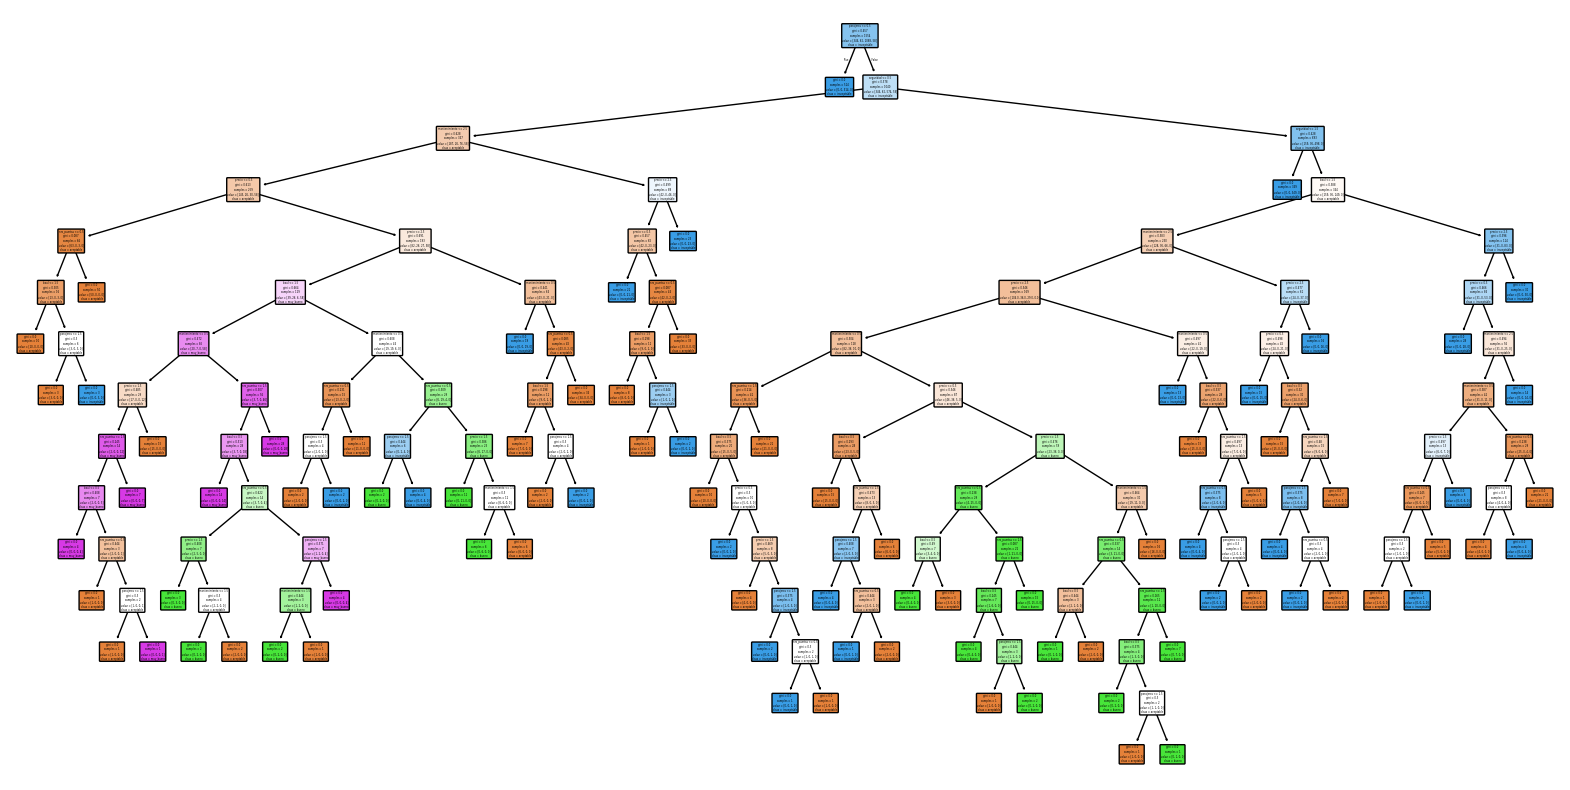

In [ ]:
# make sure the 'tree' module is imported so tree.plot_tree is defined
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
tree.plot_tree(arbol, feature_names=x_encoder.get_feature_names_out(), class_names=y_encoder.classes_, filled=True, rounded=True)
plt.show()
#no combiene este arbol tan profundo, pues se sobreajusta a los datos de entrenamiento del algortimo
